# 📊 StatsBomb Lineups & Formation Visualisation  

**Competition Focus:** La Liga (Multi-season analysis)  
**Dataset:** StatsBomb Open Data (free event & lineup data)  
**Purpose:** Extract, structure, and visualise starting lineups from StatsBomb data, enabling clear interpretation of team shapes and tactical formations across matches.  
**Methods:** Data extraction via `statsbombpy`, JSON normalisation, feature engineering, rule-based formation inference, and spatial visualisation using `mplsoccer`.  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  

**Notebook first written:** `25/04/2026`  
**Last updated:** `28/04/2026`  

> This notebook presents a structured pipeline for working with StatsBomb lineup data, focusing on extracting and visualising starting XIs in a tactically meaningful way.  
>
> Lineup data is expanded from nested JSON formats into a clean tabular structure, allowing each player’s position to be analysed consistently across matches. A rule-based approach is then used to infer team formations based on positional distributions.  
>
> To enhance interpretability, player positions are mapped onto a football pitch using `mplsoccer`, ensuring that wide, central, and defensive roles are visually distinct and aligned with real tactical structures.  
>
> The workflow is applied to individual matches as well as historical fixtures (e.g. El Clásico), enabling comparison of formations across time and opposition.  
>
> The objective is not performance evaluation, but to demonstrate how lineup data can be transformed into clear, insightful visual representations of team structure and playing shape.  

# 1. 📦 Imports & Setup

In [1]:
# Data manipulation
import pandas as pd

# StatsBomb data access
from statsbombpy import sb

# Visualisation
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# 2. 🔍 Explore Available Competitions

In [2]:
# Load all available competitions
competitions = sb.competitions()

# Filter La Liga (men's competitions only)
laliga = competitions[
    (competitions["competition_name"] == "La Liga") &
    (competitions["competition_gender"] == "male")
]

laliga.sort_values("season_name")[["competition_id", "season_id", "season_name"]]

,competition_id,season_id,season_name
55,11,278,1973/1974
54,11,37,2004/2005
53,11,38,2005/2006
52,11,39,2006/2007
51,11,40,2007/2008
50,11,41,2008/2009
49,11,21,2009/2010
48,11,22,2010/2011
47,11,23,2011/2012
46,11,24,2012/2013


# 3. ⚽ Load Matches

In [3]:
# Create list of (competition_id, season_id)
leagues = list(zip(laliga["competition_id"], laliga["season_id"]))

# Load matches across seasons
matches = pd.concat(
    [sb.matches(comp, season) for comp, season in leagues],
    ignore_index=True
)

print(f"Total matches: {len(matches)}")
matches.head()

Total matches: 868


,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2
1,3773565,2021-01-09,18:30:00.000,Spain - La Liga,2020/2021,Granada,Barcelona,0,4,available,available,2023-07-25T03:51:37.437064,2023-07-25T04:30:16.058384,18,Regular Season,Estadio Nuevo Los Cármenes,Ricardo De Burgos Bengoetxea,Diego Martínez Penas,Ronald Koeman,1.1.0,2,2
2,3773457,2021-05-16,18:30:00.000,Spain - La Liga,2020/2021,Barcelona,Celta Vigo,1,2,available,available,2022-12-02T09:26:39.496362,2023-04-27T23:03:53.506485,37,Regular Season,Spotify Camp Nou,NaN,Ronald Koeman,Eduardo Germán Coudet,1.1.0,2,2
3,3773631,2021-02-07,21:00:00.000,Spain - La Liga,2020/2021,Real Betis,Barcelona,2,3,available,available,2023-07-25T03:47:44.278651,2023-07-25T03:56:34.733180,22,Regular Season,Estadio Benito Villamarín,NaN,Manuel Luis Pellegrini Ripamonti,Ronald Koeman,1.1.0,2,2
4,3773665,2021-03-06,21:00:00.000,Spain - La Liga,2020/2021,Osasuna,Barcelona,0,2,available,available,2022-12-02T08:46:42.897589,2023-04-28T02:57:03.412841,26,Regular Season,Estadio El Sadar,Guillermo Cuadra Fernández,Jagoba Arrasate Elustondo,Ronald Koeman,1.1.0,2,2


# 4. 🎯 Select a Match & Load Lineups

In [4]:
# Example match
match_id = 3773386

# Inspect match info
matches[matches["match_id"] == match_id]

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3773386,2020-10-31,21:00:00.000,Spain - La Liga,2020/2021,Deportivo Alavés,Barcelona,1,1,available,available,2023-07-25T03:54:59.280826,2023-07-25T04:25:41.348202,8,Regular Season,Estadio de Mendizorroza,NaN,Pablo Javier Machín Díez,Ronald Koeman,1.1.0,2,2


In [5]:
# Load lineups for the match
lineups = sb.lineups(match_id=match_id)

# Select a team
team = "Barcelona"
lineup = lineups[team]

lineup.head()

,player_id,player_name,player_nickname,jersey_number,country,cards,positions
0,4447,Martin Braithwaite Christensen,Martin Braithwaite,9,Denmark,[],"[{'position_id': 21, 'position': 'Left Wing', ..."
1,5203,Sergio Busquets i Burgos,Sergio Busquets,5,Spain,"[{'time': '43:12', 'card_type': 'Yellow Card',...","[{'position_id': 9, 'position': 'Right Defensi..."
2,5211,Jordi Alba Ramos,Jordi Alba,18,Spain,[],"[{'position_id': 6, 'position': 'Left Back', '..."
3,5213,Gerard Piqué Bernabéu,Gerard Piqué,3,Spain,[],"[{'position_id': 3, 'position': 'Right Center ..."
4,5477,Ousmane Dembélé,None,11,France,[],"[{'position_id': 17, 'position': 'Right Wing',..."


# 5. 🧹 Extract the Starting XI (Core Logic)

In [6]:
def get_starting_xi(match_id: int, team: str) -> pd.DataFrame:
    """
    Extract the starting XI for a given team and match.
    """

    lineup = sb.lineups(match_id=match_id)[team].copy()

    # Expand positions
    df = lineup.explode("positions")
    pos = pd.json_normalize(df["positions"])

    df = pd.concat(
        [df.drop(columns="positions").reset_index(drop=True), pos],
        axis=1
    )

    # Filter starters
    starters = df[df["start_reason"] == "Starting XI"].copy()

    # Clean player names
    starters["player"] = (
        starters["player_nickname"]
        .fillna(starters["player_name"])
        .str.strip()
    )

    # Select relevant columns
    starters = starters[[
        "player",
        "jersey_number",
        "position"
    ]].sort_values("jersey_number")

    return starters.reset_index(drop=True)

In [7]:
starting_xi = get_starting_xi(match_id, team)
starting_xi

,player,jersey_number,position
0,Gerard Piqué,3,Right Center Back
1,Sergio Busquets,5,Right Defensive Midfield
2,Antoine Griezmann,7,Center Forward
3,Lionel Messi,10,Center Attacking Midfield
4,Ousmane Dembélé,11,Right Wing
5,Neto,13,Goalkeeper
6,Clément Lenglet,15,Left Center Back
7,Jordi Alba,18,Left Back
8,Sergi Roberto,20,Right Back
9,Frenkie de Jong,21,Left Defensive Midfield


# 6. 🧩 Simple Formation Detection

In [8]:
# Collect ALL positions + counts
position_counts = {}

for match_id in matches["match_id"]:
    try:
        lineups = sb.lineups(match_id=match_id)

        for team in lineups.keys():
            df = lineups[team]

            # Expand positions
            df_exp = df.explode("positions")
            pos = pd.json_normalize(df_exp["positions"])

            if "position" in pos.columns:
                for p in pos["position"].dropna():
                    position_counts[p] = position_counts.get(p, 0) + 1

    except Exception as e:
        # Skip problematic matches safely
        print(f"Skipped match {match_id}: {e}")

# Convert to DataFrame
positions_df = (
    pd.DataFrame(list(position_counts.items()), columns=["position", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Display results
print(f"Total unique positions: {positions_df['position'].nunique()}")
positions_df

Total unique positions: 25


,position,count
0,Left Wing,2297
1,Right Wing,2256
2,Left Center Back,2193
3,Center Forward,2177
4,Right Center Back,2172
5,Right Back,2165
6,Left Back,2080
7,Goalkeeper,1756
8,Left Center Midfield,1753
9,Right Center Midfield,1744


In [41]:
def infer_formation(df: pd.DataFrame) -> str:
    df = df[df["position"] != "Goalkeeper"].copy()
    df = df.drop_duplicates(subset="player")

    def classify(pos):
        pos = str(pos)

        if "Back" in pos:
            return "DEF"
        elif "Defensive Midfield" in pos:
            return "DM"
        elif "Attacking Midfield" in pos:
            return "AM"
        elif "Midfield" in pos:
            return "CM"
        elif any(x in pos for x in ["Wing", "Forward", "Striker"]):
            return "ATT"
        return "CM"

    df["line"] = df["position"].apply(classify)

    def_count = (df["line"] == "DEF").sum()
    dm = (df["line"] == "DM").sum()
    cm = (df["line"] == "CM").sum()
    am = (df["line"] == "AM").sum()
    att = (df["line"] == "ATT").sum()

    midfield_base = dm + cm

    # -----------------------------
    # KEY RULE (your requirement)
    # -----------------------------
    if att >= 3:
        # CAM is BETWEEN lines → NOT merged into attack
        midfield = midfield_base
        attack = att
        extra = am  # becomes separate "line" (CAM layer)
        
        formation = [def_count, midfield, extra, attack]

    else:
        # CAM can join attack if no strong front 3 exists
        attack = att + am
        formation = [def_count, midfield_base, attack]

    # remove zeros
    formation = [str(x) for x in formation if x > 0]

    return "-".join(formation)

In [42]:
formation = infer_formation(starting_xi)
print("Inferred formation:", formation)

Inferred formation: 4-2-1-3


In [43]:
# Helper: clean short names properly
def get_short_name(name: str) -> str:
    parts = name.split()

    if len(parts) >= 2 and parts[-2].lower() in [
        "de", "da", "del", "van", "von", "dos", "di", "la", "le", "ter"
    ]:
        return " ".join(parts[-2:])
    
    return parts[-1]


def plot_formation_comparison(
    match_id_1,
    match_id_2,
    team,
    team_fill="#A50044",
    team_edge="#004D98",
    number_color="white"
):

    # Load match info
    match1 = matches[matches["match_id"] == match_id_1].iloc[0]
    match2 = matches[matches["match_id"] == match_id_2].iloc[0]

    # Get data
    xi1 = get_starting_xi(match_id_1, team)
    xi2 = get_starting_xi(match_id_2, team)

    # Clean names
    xi1["short_name"] = xi1["player"].apply(get_short_name)
    xi2["short_name"] = xi2["player"].apply(get_short_name)

    # Position map (FULL StatsBomb coverage, balanced geometry)
    position_map = {
        "Goalkeeper": (5, 40),

        # Defence
        "Right Back": (20, 68),
        "Right Wing Back": (26, 72),
        "Right Center Back": (20, 55),
        "Center Back": (20, 40),
        "Left Center Back": (20, 25),
        "Left Back": (20, 12),
        "Left Wing Back": (26, 8),

        # Defensive midfield
        "Right Defensive Midfield": (42, 62),
        "Center Defensive Midfield": (42, 40),
        "Left Defensive Midfield": (42, 18),

        # Central midfield
        "Right Center Midfield": (58, 60),
        "Center Midfield": (58, 40),
        "Left Center Midfield": (58, 20),

        # Wide midfield
        "Right Midfield": (65, 72),
        "Left Midfield": (65, 8),

        # Attacking midfield
        "Center Attacking Midfield": (72, 40),
        "Left Attacking Midfield": (72, 20),
        "Right Attacking Midfield": (72, 60),

        # Attack
        "Right Wing": (88, 72),
        "Left Wing": (88, 8),

        "Right Center Forward": (92, 60),
        "Left Center Forward": (92, 20),

        "Secondary Striker": (88, 40),
        "Center Forward": (96, 40),
        "Striker": (96, 40),
    }

    # Tactical order (aligned with visual structure)
    position_order = {
        "Goalkeeper": 0,

        # Defence
        "Left Wing Back": 1,
        "Left Back": 2,
        "Left Center Back": 3,
        "Center Back": 4,
        "Right Center Back": 5,
        "Right Back": 6,
        "Right Wing Back": 7,

        # Midfield (deep → wide → attacking)
        "Left Defensive Midfield": 8,
        "Center Defensive Midfield": 9,
        "Right Defensive Midfield": 10,

        "Left Center Midfield": 11,
        "Center Midfield": 12,
        "Right Center Midfield": 13,

        "Left Midfield": 14,
        "Right Midfield": 15,

        "Left Attacking Midfield": 16,
        "Center Attacking Midfield": 17,
        "Right Attacking Midfield": 18,

        # Attack
        "Left Wing": 19,
        "Left Center Forward": 20,
        "Secondary Striker": 21,
        "Center Forward": 22,
        "Striker": 22,
        "Right Center Forward": 23,
        "Right Wing": 24,
    }

    def prepare_df(df):
        df = df.copy()

        # Map positions
        df["x"] = df["position"].map(lambda p: position_map.get(p, (50, 40))[0])
        df["y"] = df["position"].map(lambda p: position_map.get(p, (50, 40))[1])

        # Debug unmapped
        unmapped = df[~df["position"].isin(position_map.keys())]["position"].unique()
        if len(unmapped) > 0:
            print("⚠️ Unmapped positions:", unmapped)

        # Sort tactically
        df["order"] = df["position"].map(position_order).fillna(99)
        df = df.sort_values("order").drop(columns="order")

        return df

    xi1 = prepare_df(xi1)
    xi2 = prepare_df(xi2)

    # NOW infer formations (correct timing)
    form1 = infer_formation(xi1)
    form2 = infer_formation(xi2)

    # Layout
    fig = plt.figure(figsize=(14, 9), facecolor="white")
    gs = fig.add_gridspec(2, 2, height_ratios=[3.2, 1])

    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#2E7D32",
        line_color="#FAFAFA",
        linewidth=1.2
    )

    axes_pitch = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    axes_text = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

    for ax, ax_txt, df, formation, match in zip(
        axes_pitch, axes_text,
        [xi1, xi2],
        [form1, form2],
        [match1, match2]
    ):
        pitch.draw(ax=ax)

        # Players
        pitch.scatter(
            df["x"], df["y"],
            s=720,
            color=team_fill,
            edgecolors=team_edge,
            linewidth=2,
            ax=ax,
            zorder=2
        )

        # Numbers
        for _, row in df.iterrows():
            ax.text(
                row["x"], row["y"],
                str(int(row["jersey_number"])),
                ha="center", va="center",
                fontsize=11,
                color=number_color,
                weight="bold",
                zorder=3
            )

        # Names
        for _, row in df.iterrows():
            ax.text(
                row["x"], row["y"] - 5.8,
                row["short_name"],
                ha="center",
                va="center",
                fontsize=11,
                weight="bold",
                color="white"
            )

        # Titles
        match_date = pd.to_datetime(match["match_date"]).strftime("%d %b %Y")

        ax.set_title(
            f"{match['home_team']} {match['home_score']}–{match['away_score']} {match['away_team']}",
            fontsize=14,
            weight="bold",
            color="#111111",
            pad=22
        )

        ax.text(
            0.5, 1.02,
            f"{match_date} • Formation: {formation}",
            transform=ax.transAxes,
            ha="center",
            fontsize=12,
            color="#333333"
        )

        # TEXT PANEL
        ax_txt.axis("off")

        lines = [
            f"{row['position']:<30} {row['player']} ({int(row['jersey_number'])})"
            for _, row in df.iterrows()
        ]

        ax_txt.text(
            0.02, 0.95,
            "\n".join(lines),
            va="top",
            fontsize=10,
            family="monospace",
            color="#222222"
        )

    # Main title
    fig.suptitle(
        f"{team} - Starting XI Comparison",
        fontsize=18,
        weight="bold",
        color="#111111",
        y=0.925
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

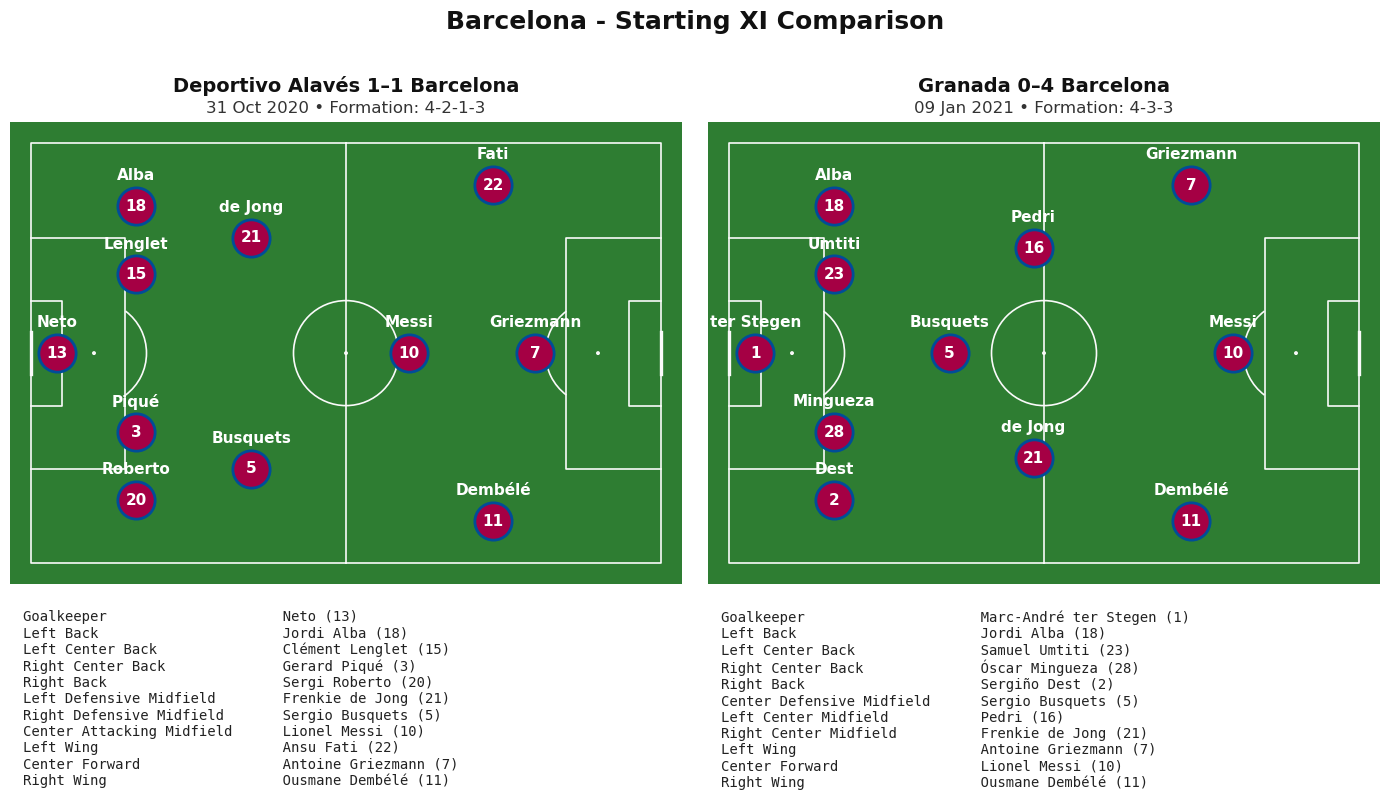

In [44]:
plot_formation_comparison(
    match_id_1=3773386,
    match_id_2=3773565,
    team="Barcelona",
    team_fill="#A50044",
    team_edge="#004D98",
    number_color="white"
)

In [45]:
# Filter El Clásico matches
clasicos = matches[
    (
        ((matches["home_team"] == "Barcelona") & (matches["away_team"] == "Real Madrid")) |
        ((matches["home_team"] == "Real Madrid") & (matches["away_team"] == "Barcelona"))
    )
].sort_values("match_date").reset_index(drop=True)


# Compute formations
clasicos["home_formation"] = clasicos.apply(
    lambda row: infer_formation(get_starting_xi(row["match_id"], row["home_team"])),
    axis=1
)

clasicos["away_formation"] = clasicos.apply(
    lambda row: infer_formation(get_starting_xi(row["match_id"], row["away_team"])),
    axis=1
)


# Final table
clasicos_table = clasicos[[
    "match_id",
    "match_date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "home_formation",
    "away_formation"
]]

clasicos_table

,match_id,match_date,home_team,away_team,home_score,away_score,home_formation,away_formation
0,3888713,1974-02-17,Real Madrid,Barcelona,0,5,3-3-3,4-3-3
1,68319,2005-11-19,Real Madrid,Barcelona,0,3,4-2-1-3,4-3-3
2,68330,2006-10-22,Real Madrid,Barcelona,2,0,4-2-1-3,4-3-3
3,68335,2007-03-10,Barcelona,Real Madrid,3,3,3-4-3,4-2-1-3
4,68361,2008-05-07,Real Madrid,Barcelona,4,1,4-2-1-3,4-3-3
5,69225,2008-12-13,Barcelona,Real Madrid,2,0,4-3-3,4-4-2
6,69249,2009-05-02,Real Madrid,Barcelona,2,6,4-4-2,4-3-3
7,69262,2009-11-29,Barcelona,Real Madrid,1,0,4-3-3,4-2-1-3
8,69259,2010-04-10,Real Madrid,Barcelona,0,2,4-3-3,4-3-3
9,69299,2010-11-29,Barcelona,Real Madrid,5,0,4-3-3,4-2-1-3


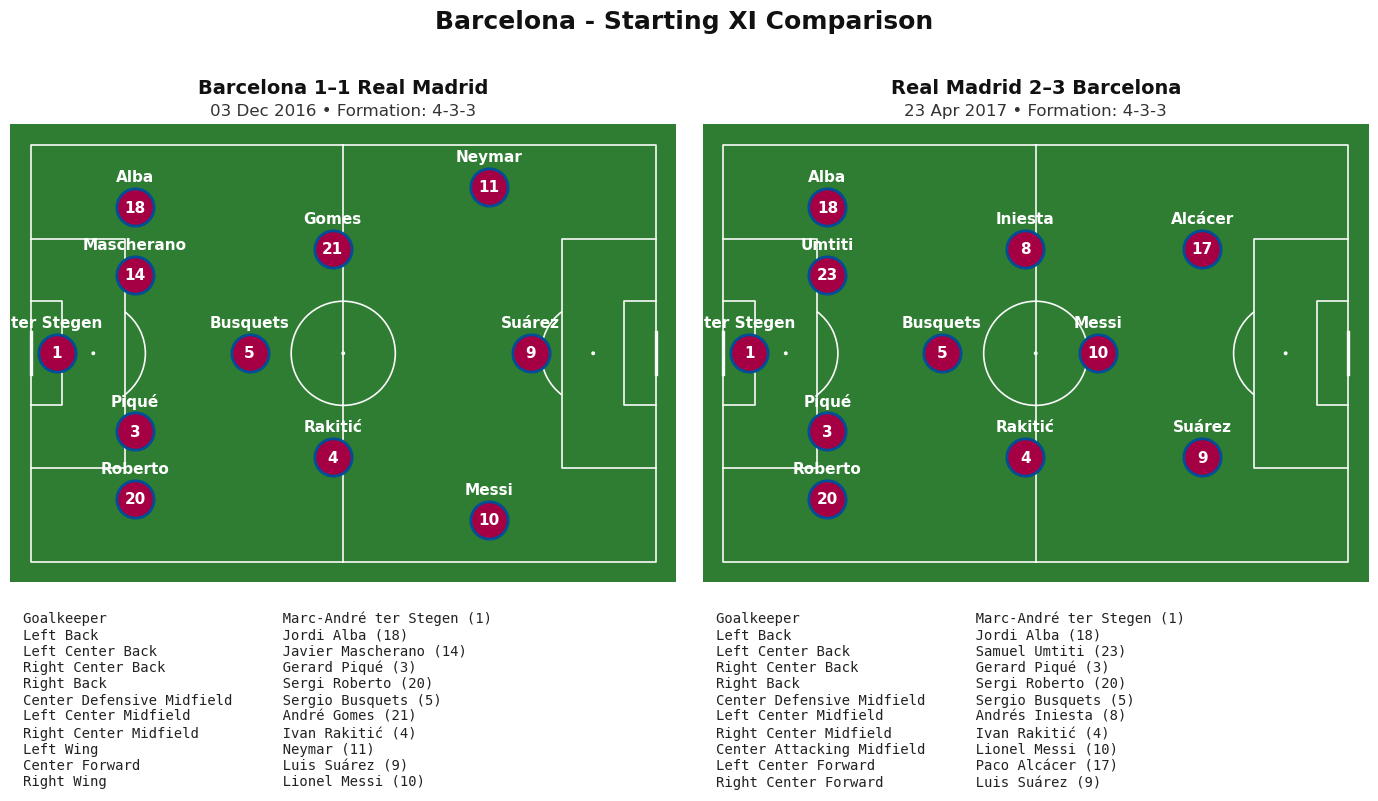

In [46]:
plot_formation_comparison(
    match_id_1=267076,
    match_id_2=267569,
    team="Barcelona",
    team_fill="#A50044",
    team_edge="#004D98",
    number_color="white"
)

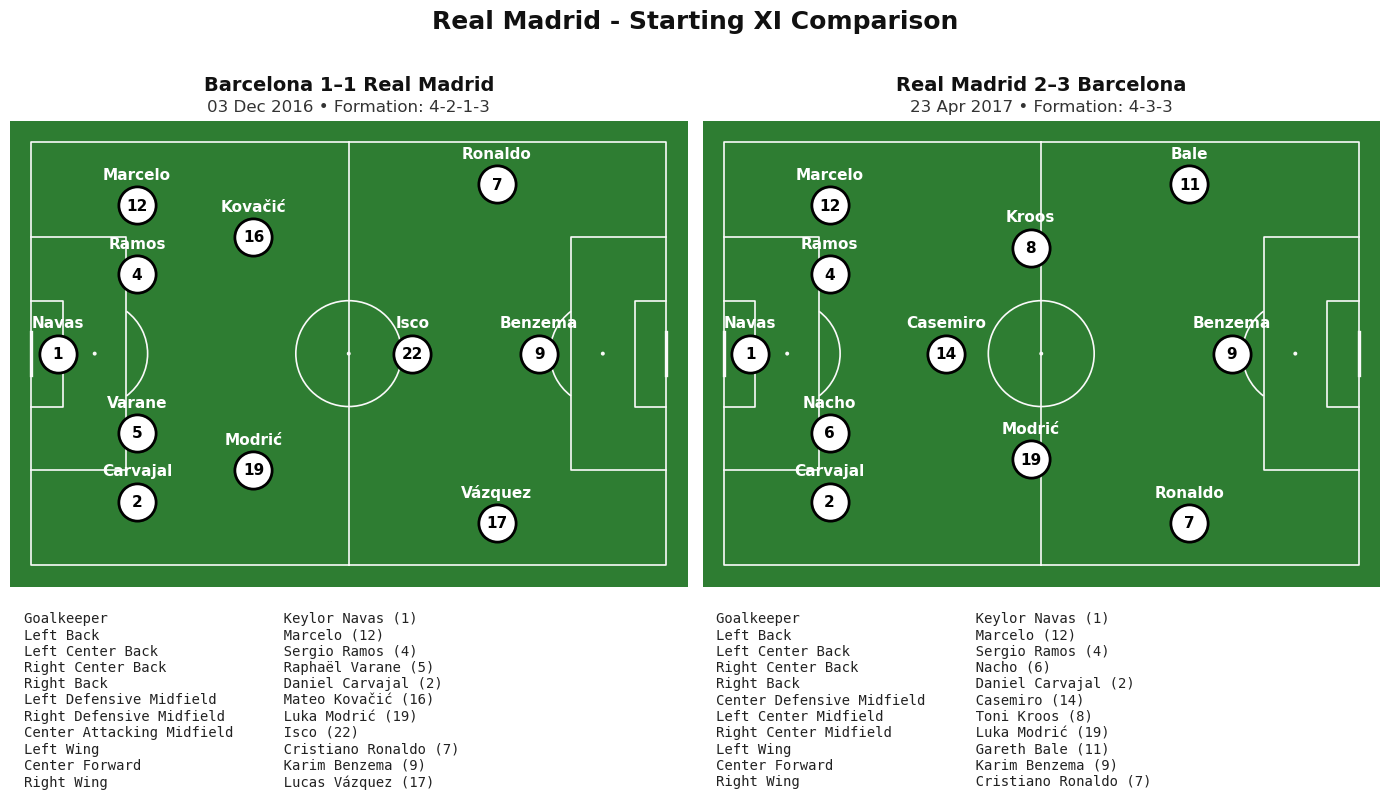

In [47]:
plot_formation_comparison(
    match_id_1=267076,
    match_id_2=267569,
    team="Real Madrid",
    team_fill="white",
    team_edge="black",
    number_color="black"
)

In [32]:
barca_matches = matches[
    (matches["home_team"] == "Barcelona") |
    (matches["away_team"] == "Barcelona")
]

formations = []

for m_id in barca_matches["match_id"].head(20):  # limit for speed
    try:
        xi = get_starting_xi(m_id, "Barcelona")
        formation = infer_formation(xi)

        formations.append(formation)
    except:
        continue

pd.Series(formations).value_counts()

4-3-3      6
5-3-2      6
4-2-1-3    4
5-2-3      1
4-4-2      1
4-5-1      1
5-2-2-1    1
Name: count, dtype: int64